![tower_bridge](tower_bridge.jpeg)

As the climate changes, predicting the weather becomes ever more important for businesses. Since the weather depends on a lot of different factors, you will want to run a lot of experiments to determine what the best approach is to predict the weather. In this project, you will run experiments for different regression models predicting the mean temperature, using a combination of `sklearn` and `MLflow`.

You will be working with data stored in `london_weather.csv`, which contains the following columns:
- **date** - recorded date of measurement - (**int**)
- **cloud_cover** - cloud cover measurement in oktas - (**float**)
- **sunshine** - sunshine measurement in hours (hrs) - (**float**)
- **global_radiation** - irradiance measurement in Watt per square meter (W/m2) - (**float**)
- **max_temp** - maximum temperature recorded in degrees Celsius (°C) - (**float**)
- **mean_temp** - mean temperature in degrees Celsius (°C) - (**float**)
- **min_temp** - minimum temperature recorded in degrees Celsius (°C) - (**float**)
- **precipitation** - precipitation measurement in millimeters (mm) - (**float**)
- **pressure** - pressure measurement in Pascals (Pa) - (**float**)
- **snow_depth** - snow depth measurement in centimeters (cm) - (**float**)

In [36]:
# Run this cell to import the modules you require
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Read in the data
weather = pd.read_csv("london_weather.csv")

# Start coding here
# Use as many cells as you like
print(weather.info())
print(weather.describe())
print(weather.isna().sum())
print(weather.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15341 entries, 0 to 15340
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              15341 non-null  int64  
 1   cloud_cover       15322 non-null  float64
 2   sunshine          15341 non-null  float64
 3   global_radiation  15322 non-null  float64
 4   max_temp          15335 non-null  float64
 5   mean_temp         15305 non-null  float64
 6   min_temp          15339 non-null  float64
 7   precipitation     15335 non-null  float64
 8   pressure          15337 non-null  float64
 9   snow_depth        13900 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 1.2 MB
None
               date   cloud_cover  ...       pressure    snow_depth
count  1.534100e+04  15322.000000  ...   15337.000000  13900.000000
mean   1.999567e+07      5.268242  ...  101536.605594      0.037986
std    1.212176e+05      2.070072  ...    1049.722604      0.545633


In [37]:
weather['date']=pd.to_datetime(weather['date'], format="%Y%m%d", errors='coerce')

In [38]:
weather['year']=weather['date'].dt.year
weather['month']=weather['date'].dt.month

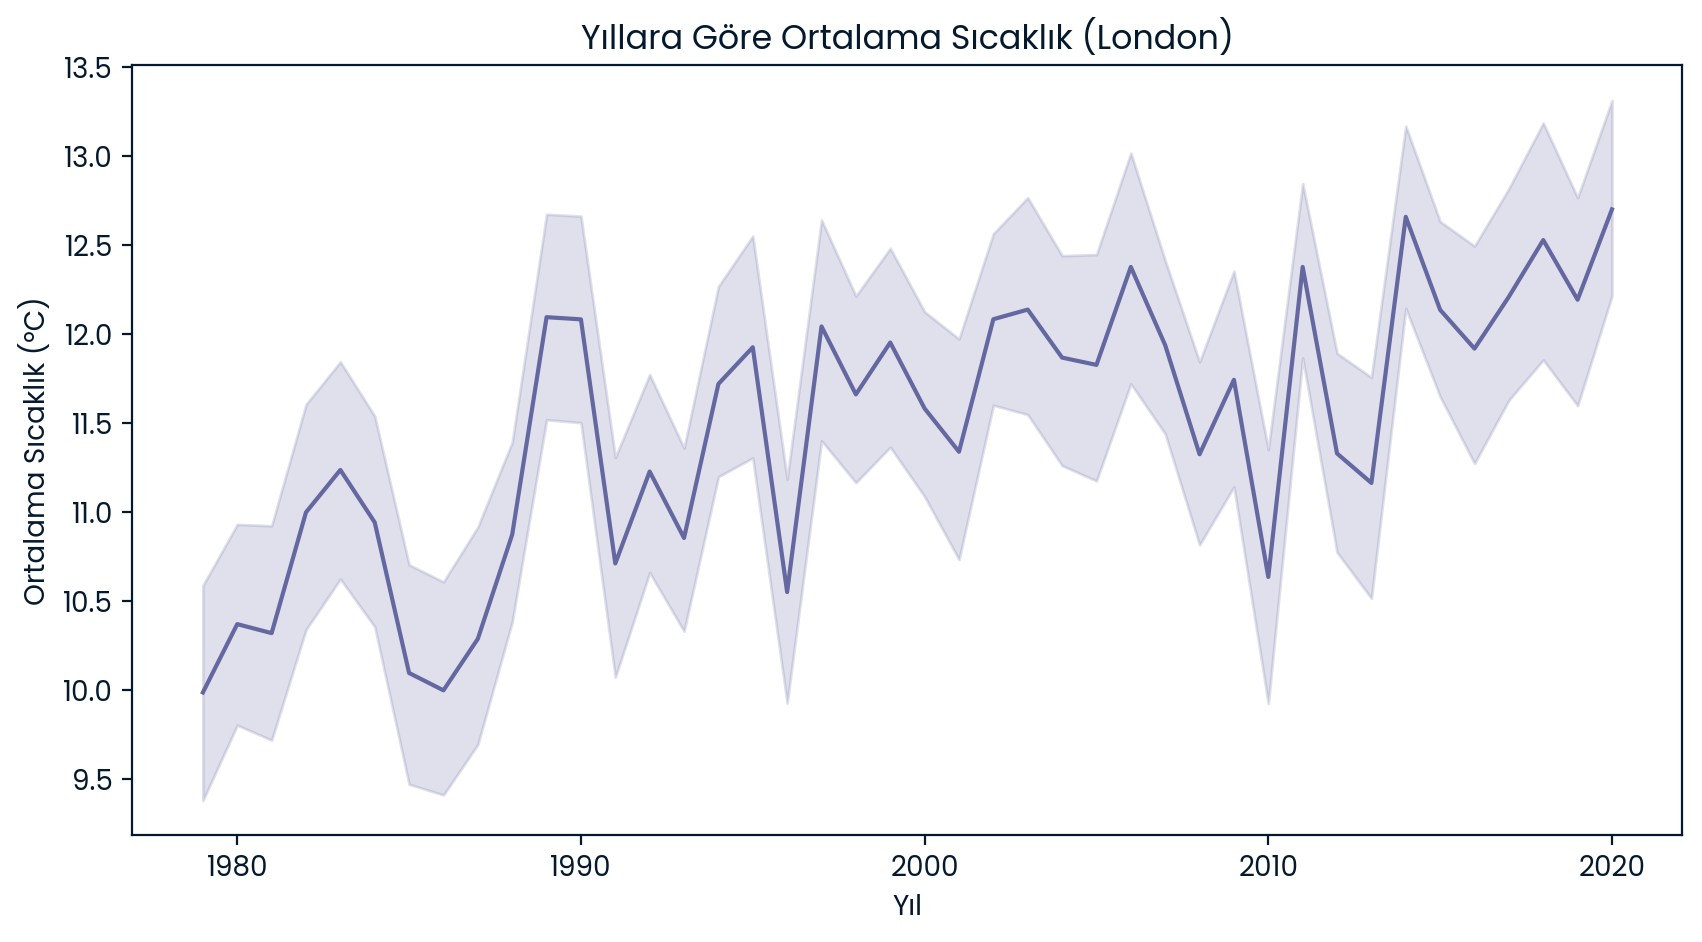

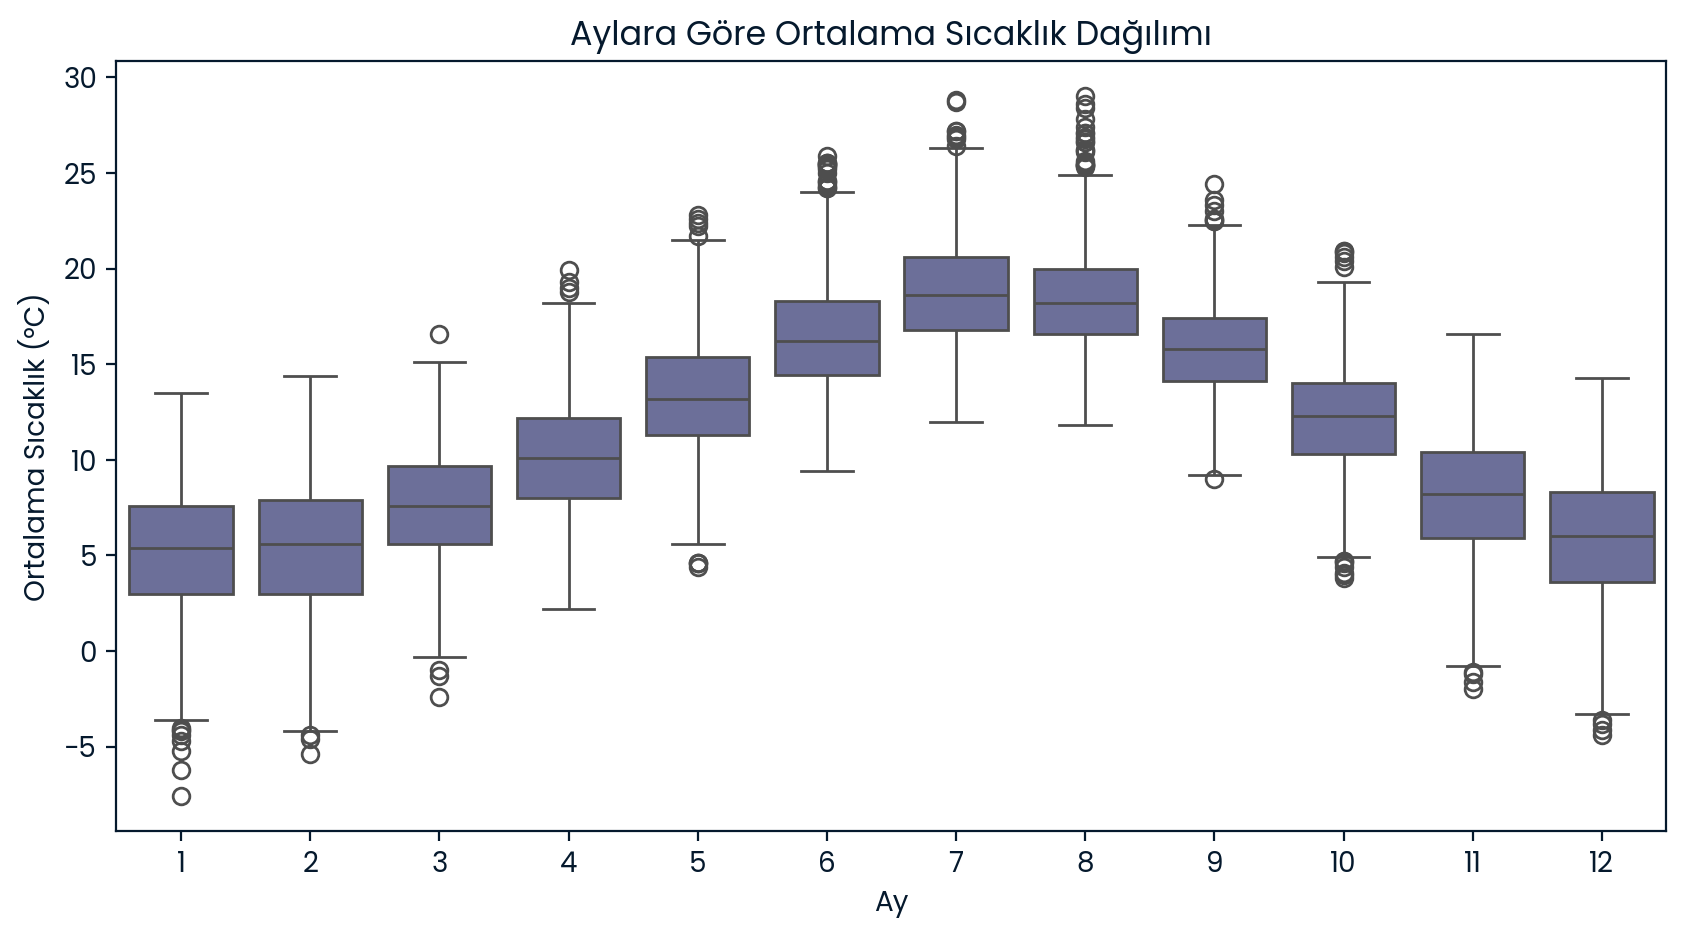

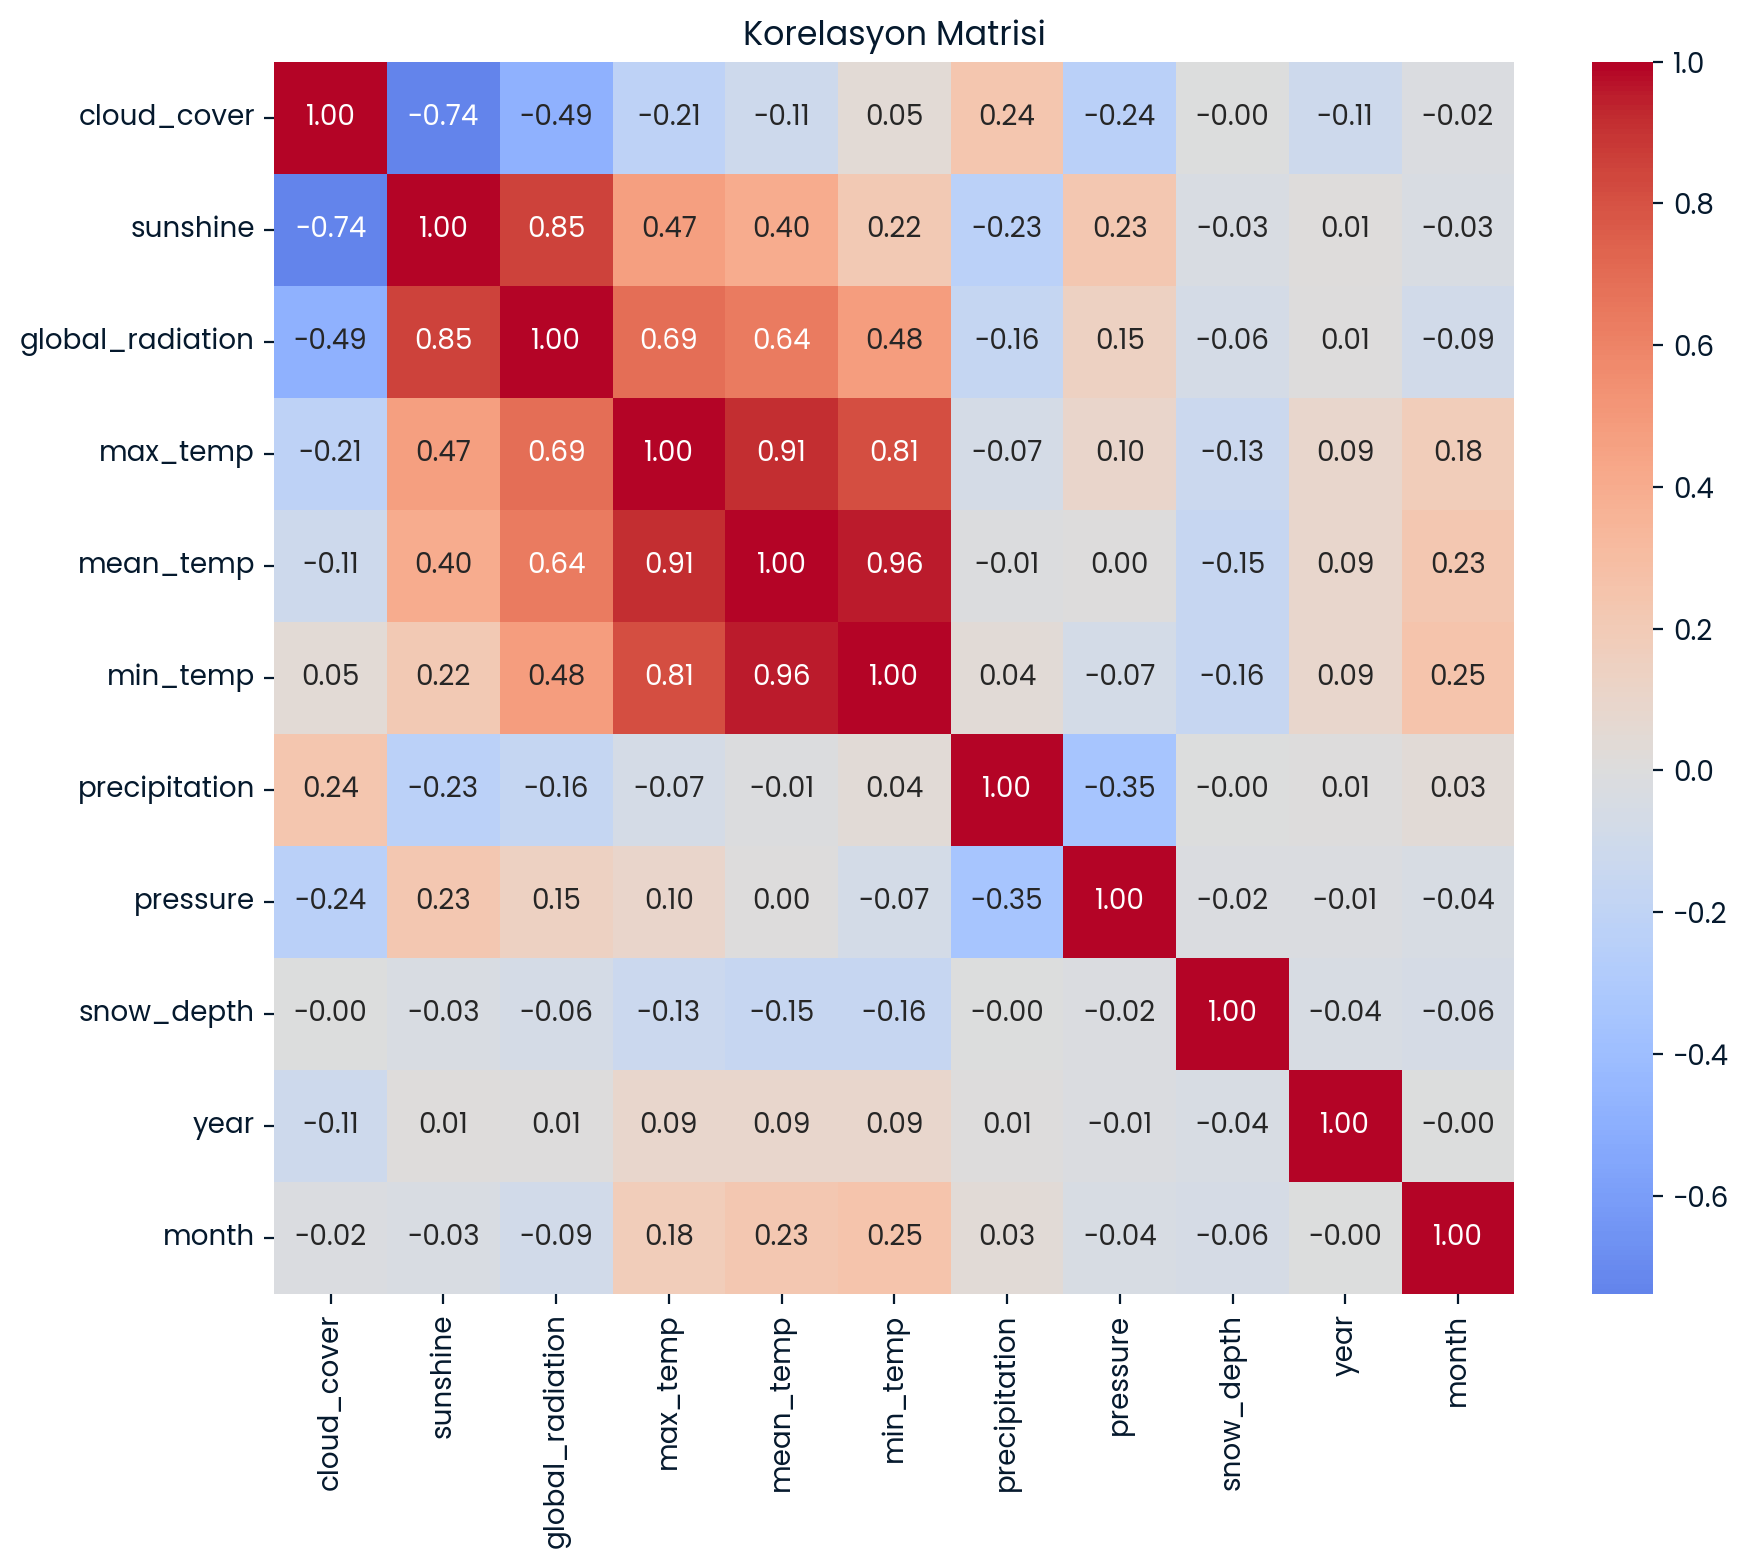

In [39]:
# 1) Yıllara göre ortalama sıcaklık
plt.figure(figsize=(10,5))
sns.lineplot(data=weather, x="year", y="mean_temp")
plt.title("Yıllara Göre Ortalama Sıcaklık (London)")
plt.xlabel("Yıl")
plt.ylabel("Ortalama Sıcaklık (°C)")
plt.show()

# 2) Aylara göre ortalama sıcaklık
plt.figure(figsize=(10,5))
sns.boxplot(data=weather, x="month", y="mean_temp")
plt.title("Aylara Göre Ortalama Sıcaklık Dağılımı")
plt.xlabel("Ay")
plt.ylabel("Ortalama Sıcaklık (°C)")
plt.show()

# 3) Korelasyon matrisi
plt.figure(figsize=(10,8))
corr = weather.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korelasyon Matrisi")
plt.show()

In [40]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

# 1) Feature ve target setlerini ayır
X = weather[[
    "cloud_cover", "sunshine", "global_radiation",
    "max_temp", "min_temp", "precipitation",
    "pressure", "snow_depth", "year", "month"
]]
y = weather["mean_temp"]

# 2) Hedefte eksik olan satırları baştan düşür
data = pd.concat([X, y], axis=1).dropna(subset=["mean_temp"])
X = data[X.columns]
y = data["mean_temp"]

# 3) Train-test split (model değerlendirmesi için)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4) Pipeline: imputer + scaler + feature selection + model
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(score_func=f_regression)),  # k parametresi GridSearch'te aranacak
    ("model", LinearRegression())
])

# 5) GridSearch ile en iyi k'yı bulma
param_grid = {
    "selector__k": range(2, X.shape[1] + 1)  # 2 ile tüm feature sayısı arasında ara
}

grid = GridSearchCV(pipeline, param_grid, scoring='neg_root_mean_squared_error', cv=5)
grid.fit(X_train, y_train)

# 6) En iyi sonucu yazdır
print("En iyi k:", grid.best_params_["selector__k"])
print("CV En iyi RMSE:", -grid.best_score_)

# 7) Test seti performansı
y_pred = grid.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", test_rmse)

# 8) Seçilen feature'lar
best_selector = grid.best_estimator_.named_steps["selector"]
selected_features = X.columns[best_selector.get_support()]
print("Seçilen Özellikler:", selected_features.tolist())

En iyi k: 10
CV En iyi RMSE: 0.8873204446074441
Test RMSE: 0.8731799539343437
Seçilen Özellikler: ['cloud_cover', 'sunshine', 'global_radiation', 'max_temp', 'min_temp', 'precipitation', 'pressure', 'snow_depth', 'year', 'month']


In [41]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# MLflow denemelerini "weather_experiments" adlı experimente kaydedelim
mlflow.set_experiment("weather_experiments")

# Denenecek modeller
models = [
    ("LinearRegression", LinearRegression(), {}),
    ("DecisionTree_depth3", DecisionTreeRegressor(max_depth=3), {"max_depth": 3}),
    ("DecisionTree_depth5", DecisionTreeRegressor(max_depth=5), {"max_depth": 5}),
    ("RandomForest_depth3", RandomForestRegressor(max_depth=3, n_estimators=100), {"max_depth": 3, "n_estimators": 100}),
    ("RandomForest_depth5", RandomForestRegressor(max_depth=5, n_estimators=100), {"max_depth": 5, "n_estimators": 100})
]

for model_name, model, params in models:
    with mlflow.start_run(run_name=model_name):
        # Pipeline oluştur
        pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler()),
            ("model", model)
        ])
        
        # Eğit
        pipeline.fit(X_train, y_train)
        
        # Tahmin ve RMSE
        y_pred = pipeline.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        # Parametreleri logla
        mlflow.log_params(params)
        
        # Metrik logla
        mlflow.log_metric("rmse", rmse)
        
        # Modeli kaydet
        mlflow.sklearn.log_model(pipeline, model_name)

        print(f"{model_name} RMSE: {rmse}")

# Tüm sonuçları al
experiment_results = mlflow.search_runs(experiment_names=["weather_experiments"])
experiment_results.head()


LinearRegression RMSE: 0.8731799539343437
DecisionTree_depth3 RMSE: 1.7869688250454723
DecisionTree_depth5 RMSE: 1.2616091843051458
RandomForest_depth3 RMSE: 1.6352250474737196
RandomForest_depth5 RMSE: 1.0707816745039982


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.rmse,params.n_estimators,params.max_depth,tags.mlflow.source.type,tags.mlflow.log-model.history,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.source.name
0,c89f4bc65fb34afa85e28b9fada71c76,830368462796393602,FINISHED,file:///work/files/workspace/mlruns/8303684627...,2025-08-15 16:48:41.040000+00:00,2025-08-15 16:48:46.320000+00:00,1.070782,100,5,LOCAL,"[{""run_id"": ""c89f4bc65fb34afa85e28b9fada71c76""...",repl,RandomForest_depth5,/usr/lib/python3/dist-packages/python_kernel/k...
1,a1d7771c89184400afb703ae936c039b,830368462796393602,FINISHED,file:///work/files/workspace/mlruns/8303684627...,2025-08-15 16:48:36.237000+00:00,2025-08-15 16:48:40.946000+00:00,1.635225,100,3,LOCAL,"[{""run_id"": ""a1d7771c89184400afb703ae936c039b""...",repl,RandomForest_depth3,/usr/lib/python3/dist-packages/python_kernel/k...
2,225bd0825e1d4f3f967f6996f30fbfca,830368462796393602,FINISHED,file:///work/files/workspace/mlruns/8303684627...,2025-08-15 16:48:32.508000+00:00,2025-08-15 16:48:36.138000+00:00,1.261609,None,5,LOCAL,"[{""run_id"": ""225bd0825e1d4f3f967f6996f30fbfca""...",repl,DecisionTree_depth5,/usr/lib/python3/dist-packages/python_kernel/k...
3,6f5029decbe548b1ab23aa4178595e5b,830368462796393602,FINISHED,file:///work/files/workspace/mlruns/8303684627...,2025-08-15 16:48:28.884000+00:00,2025-08-15 16:48:32.416000+00:00,1.786969,None,3,LOCAL,"[{""run_id"": ""6f5029decbe548b1ab23aa4178595e5b""...",repl,DecisionTree_depth3,/usr/lib/python3/dist-packages/python_kernel/k...
4,e2f1cf50fab14bc0b429b0fb91aab268,830368462796393602,FINISHED,file:///work/files/workspace/mlruns/8303684627...,2025-08-15 16:48:25.217000+00:00,2025-08-15 16:48:28.782000+00:00,0.873180,None,None,LOCAL,"[{""run_id"": ""e2f1cf50fab14bc0b429b0fb91aab268""...",repl,LinearRegression,/usr/lib/python3/dist-packages/python_kernel/k...
